## Classification Model using the Kickstarter datasets
- The model aims to predict whether a project’s state is “successful” or “failed" at the time of launch
- To ensure model performance of predictions, features only available at the time of project launch are used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("kickstarter_combined.csv")
df.head()

,backers_count,blurb,category,converted_pledged_amount,country,country_displayable_name,created_at,creator,currency,currency_symbol,...,spotlight,staff_pick,state,state_changed_at,static_usd_rate,urls,usd_exchange_rate,usd_pledged,usd_type,video
0,20,A photographic book of a festival celebrated b...,"{""id"":278,""name"":""People"",""analytics_name"":""Pe...",637.0,GB,the United Kingdom,1724064660,"{""id"":729000581,""name"":""Neil Martinson"",""slug""...",GBP,£,...,False,False,failed,1727098184,1.320305,"{""web"":{""project"":""https://www.kickstarter.com...",1.330982,632.425889,domestic,"{""id"":1312771,""status"":""successful"",""hls"":""htt..."
1,531,Unlock the Full Potential of Your Steam Deck w...,"{""id"":52,""name"":""Hardware"",""analytics_name"":""H...",83872.0,US,the United States,1746583126,"{""id"":767329947,""name"":""Seesaw"",""slug"":""dockca...",USD,$,...,False,True,live,1761051614,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,83872.000000,domestic,"{""id"":1367591,""status"":""successful"",""hls"":""htt..."
2,0,Retagger Mobile: Transform the Internet with S...,"{""id"":332,""name"":""Apps"",""analytics_name"":""Apps...",0.0,US,the United States,1731435583,"{""id"":1696039535,""name"":""Donnie Bugden"",""slug""...",USD,$,...,False,False,live,1760906735,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,0.000000,domestic,"{""id"":1392212,""status"":""successful"",""hls"":""htt..."
3,166,Help support the making and release of Armchai...,"{""id"":37,""name"":""Country & Folk"",""analytics_na...",12314.0,US,the United States,1548701666,"{""id"":1417057582,""name"":""Armchair Boogie"",""slu...",USD,$,...,True,True,successful,1559659892,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,12314.860000,domestic,"{""id"":955599,""status"":""successful"",""hls"":""http..."
4,66,When you buy MatchBack's premier graphic tee &...,"{""id"":263,""name"":""Apparel"",""analytics_name"":""A...",5599.0,US,the United States,1496003666,"{""id"":2025826474,""name"":""Aaron Podell"",""is_reg...",USD,$,...,True,False,successful,1498892340,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,5599.000000,domestic,"{""id"":787581,""status"":""successful"",""hls"":null,..."


In [3]:
df.shape

(265019, 42)

In [4]:
df.columns

Index(['backers_count', 'blurb', 'category', 'converted_pledged_amount',
       'country', 'country_displayable_name', 'created_at', 'creator',
       'currency', 'currency_symbol', 'currency_trailing_code',
       'current_currency', 'deadline', 'disable_communication', 'fx_rate',
       'goal', 'id', 'is_disliked', 'is_in_post_campaign_pledging_phase',
       'is_launched', 'is_liked', 'is_starrable', 'launched_at', 'location',
       'name', 'percent_funded', 'photo', 'pledged', 'prelaunch_activated',
       'profile', 'slug', 'source_url', 'spotlight', 'staff_pick', 'state',
       'state_changed_at', 'static_usd_rate', 'urls', 'usd_exchange_rate',
       'usd_pledged', 'usd_type', 'video'],
      dtype='object')

## Data Prep

#### Clean up target variable

In [5]:
df['state'].value_counts()

state
successful    152296
failed         77302
submitted      13782
live            9494
canceled        9352
started         2783
suspended         10
Name: count, dtype: int64

In [6]:
df = df[df['state'].isin(['successful', 'failed'])].copy()
df['target'] = (df['state'] == 'successful').astype(int)
df['state'].value_counts()

state
successful    152296
failed         77302
Name: count, dtype: int64

In [7]:
df['target'].value_counts()

target
1    152296
0     77302
Name: count, dtype: int64

#### Limit to the columns only available at the time of launch

In [8]:
launch_cols = [
    'blurb', 'category', 'country', 'country_displayable_name', 'created_at', 'creator',
    'currency', 'currency_symbol', 'currency_trailing_code', 'current_currency',
    'deadline', 'disable_communication', 'fx_rate', 'goal', 'id', 'is_launched',
    'is_starrable', 'launched_at', 'location', 'name', 'prelaunch_activated',
    'profile', 'slug', 'source_url', 'urls', 'video', 'static_usd_rate'
]

target_col = ['target']

df = df[launch_cols + target_col].copy()
df.columns

Index(['blurb', 'category', 'country', 'country_displayable_name',
       'created_at', 'creator', 'currency', 'currency_symbol',
       'currency_trailing_code', 'current_currency', 'deadline',
       'disable_communication', 'fx_rate', 'goal', 'id', 'is_launched',
       'is_starrable', 'launched_at', 'location', 'name',
       'prelaunch_activated', 'profile', 'slug', 'source_url', 'urls', 'video',
       'static_usd_rate', 'target'],
      dtype='object')

#### Look into several columns (especially JSON type) to extract meaningful data

In [9]:
df['creator'].iloc[0]

'{"id":729000581,"name":"Neil Martinson","slug":"neilmartinson","is_registered":null,"is_email_verified":null,"chosen_currency":null,"is_superbacker":null,"has_admin_message_badge":false,"ppo_has_action":true,"backing_action_count":1,"avatar":{"thumb":"https://i.kickstarter.com/assets/046/134/850/47ee76af4cfa795fae1cdc38e2c13732_original.jpeg?anim=false&fit=cover&height=40&origin=ugc&q=92&v=1724083823&width=40&sig=NxEC28FWqX8yAWmBIbcl2MqQnxgi20IukYgYnEuZ%2BkY%3D","small":"https://i.kickstarter.com/assets/046/134/850/47ee76af4cfa795fae1cdc38e2c13732_original.jpeg?anim=false&fit=cover&height=80&origin=ugc&q=92&v=1724083823&width=80&sig=1LfKfrfMNddz08MoFk41khqa%2BAtAjEC626LMVSa%2F4Tk%3D","medium":"https://i.kickstarter.com/assets/046/134/850/47ee76af4cfa795fae1cdc38e2c13732_original.jpeg?anim=false&fit=cover&height=160&origin=ugc&q=92&v=1724083823&width=160&sig=eSoEchKu3w5skqTbMT4W90mIHKzkyEwqrxI21C7%2FyNQ%3D"},"urls":{"web":{"user":"https://www.kickstarter.com/profile/neilmartinson"},"ap

In [10]:
df['location'].iloc[0]

'{"id":24875637,"name":"Hackney","slug":"hackney-london-gb","short_name":"Hackney, UK","displayable_name":"Hackney, UK","localized_name":"Hackney","country":"GB","state":"England","type":"Suburb","is_root":false,"expanded_country":"United Kingdom","urls":{"web":{"discover":"https://www.kickstarter.com/discover/places/hackney-london-gb","location":"https://www.kickstarter.com/locations/hackney-london-gb"},"api":{"nearby_projects":"https://api.kickstarter.com/v1/discover?signature=1763004121.31221665ef69c67315ea2aa3670d24dfdfc8069f&woe_id=24875637"}}}'

In [11]:
df['category'].iloc[0]

'{"id":278,"name":"People","analytics_name":"People","slug":"photography/people","position":4,"parent_id":15,"parent_name":"Photography","color":58341,"urls":{"web":{"discover":"http://www.kickstarter.com/discover/categories/photography/people"}}}'

#### While "creator" and "location" don't give much new information, "category" can be useful especially parent_name seems like the main category of the campaign. As such, let's makde a new column based on this.

In [12]:
import json

def extract_parent_name(x):
    try:
        data = json.loads(x)  
        return data.get('parent_name', None)  
    except (json.JSONDecodeError, TypeError):
        return None  

df['main_category'] = df['category'].apply(extract_parent_name)

print(df['main_category'].iloc[0:21])

df = df.drop(columns=['category'])

0     Photography
3           Music
4         Fashion
5         Fashion
9           Music
10          Music
11          Music
12          Music
13            Art
14            Art
15            Art
16        Fashion
19            Art
20            Art
21        Fashion
22        Fashion
23        Fashion
24        Fashion
25          Music
26          Music
33            Art
Name: main_category, dtype: object


In [13]:
df['video'].unique

<bound method Series.unique of 0         {"id":1312771,"status":"successful","hls":"htt...
3         {"id":955599,"status":"successful","hls":"http...
4         {"id":787581,"status":"successful","hls":null,...
5         {"id":784413,"status":"successful","hls":null,...
9         {"id":951822,"status":"successful","hls":"http...
                                ...                        
265012                                                  NaN
265013    {"id":800427,"status":"successful","hls":null,...
265014                                                  NaN
265017    {"id":878717,"status":"successful","hls":"http...
265018                                                  NaN
Name: video, Length: 229598, dtype: object>

In [14]:
# values in video column look JSON and hard to interpret, thus switch it to binary (video yes:1 no:0)
df['has_video'] = df['video'].notna().astype(int)
df = df.drop(columns=['video'])

#### Standardize the goal based on USD

In [15]:
# Use static_usd_rate for goal (target fundraising amount)
df['goal_usd_static'] = df['goal'] * df['static_usd_rate']

# As we use static_rate, we drop fx_rate
df = df.drop(columns=['goal', 'static_usd_rate', 'fx_rate'])

#### Campaign duration calculation

In [16]:
df['campaign_duration_days'] = (df['deadline'] - df['launched_at']) / (24*3600)

#### Preparation duration calculation

In [17]:
df['preparation_duration_days'] = (df['launched_at'] - df['created_at']) / (24*3600)

# delete the origial columns
df = df.drop(columns=['deadline', 'launched_at', 'created_at'])

#### Check length of name and description

In [18]:
df['name_len'] = df['name'].fillna('').apply(len)
df['blurb_len'] = df['blurb'].fillna('').apply(len)
df = df.drop(columns=['name', 'blurb'])

## Handle missing values

In [19]:
missing_counts = df.isna().sum()
print(missing_counts)

country                         0
country_displayable_name        0
creator                         0
currency                        0
currency_symbol                 0
currency_trailing_code          0
current_currency                0
disable_communication           0
id                              0
is_launched                     0
is_starrable                    0
location                      152
prelaunch_activated             0
profile                         0
slug                            0
source_url                      0
urls                            0
target                          0
main_category                4454
has_video                       0
goal_usd_static                 0
campaign_duration_days          0
preparation_duration_days       0
name_len                        0
blurb_len                       0
dtype: int64


In [20]:
# Compared to the number of entire rows, there are not many missing values. So, let's drop them
df = df.dropna()

## Categorize features and remove non-relevant columns

In [21]:
# Numerical columns
num_cols = [
    'goal_usd_static',
    'campaign_duration_days',
    'preparation_duration_days',
    'name_len',
    'blurb_len',
    'has_video'                 
]

# Categorical
cat_cols = [
    'country',                  
    'main_category'
]

# Boolean columns
bool_cols = ['disable_communication', 'prelaunch_activated']


# Non-critical columns for the model
non_critic_cols = [
    'id',                        # project ID
    'country_displayable_name',  # duplicate information (captued in 'country' column)
    'creator',                   # not important for modeling
    'currency',                  # currency code
    'currency_symbol',           # not important for modeling
    'currency_trailing_code',   
    'current_currency',          # whether the goal is in USD or EUR
    'is_launched',               # all True
    'is_starrable',              # all False
    'profile',                   # duplicate information23
    'slug',                      # not important for modeling
    'source_url',                # not important for modeling
    'urls',                      # not important for modeling
    'location',                  # not important for modeling
]

In [22]:
df = df.drop(columns=non_critic_cols)
df.head()

,country,disable_communication,prelaunch_activated,target,main_category,has_video,goal_usd_static,campaign_duration_days,preparation_duration_days,name_len,blurb_len
0,GB,False,True,0,Photography,1,1980.456855,27.00000,8.110012,16,90
3,US,False,False,1,Music,1,12000.000000,35.00000,91.831319,49,71
4,US,False,False,1,Fashion,1,5000.000000,22.08691,11.346817,46,130
5,HK,False,False,1,Fashion,1,7700.857800,38.00000,128.156493,42,124
9,US,False,False,1,Music,1,22661.000000,30.00000,94.860810,53,127


## Check outliers

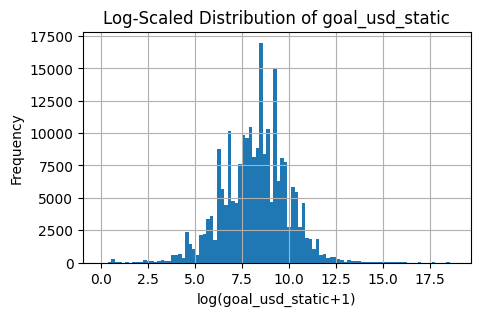

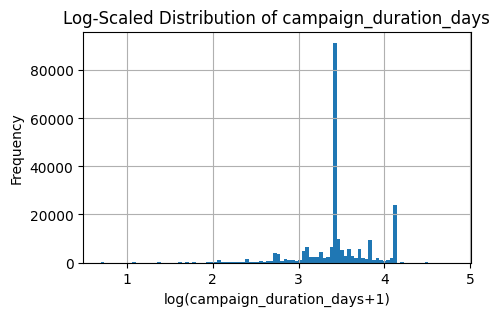

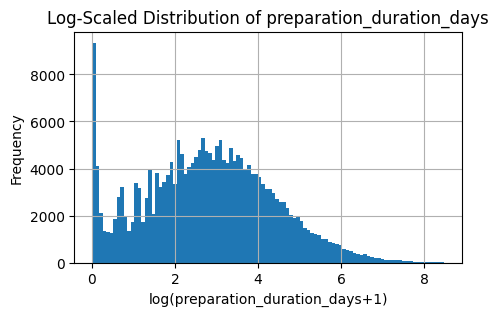

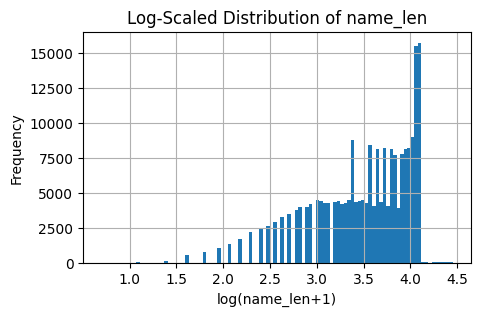

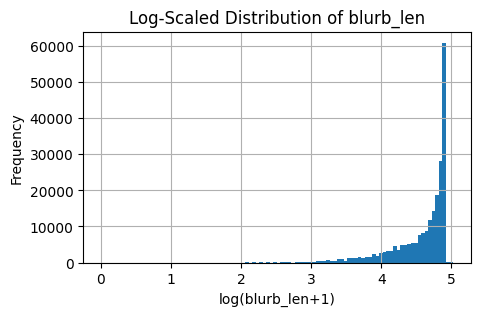

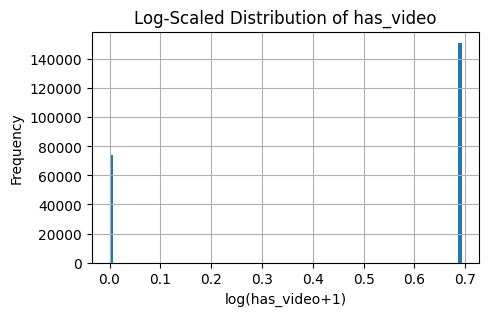

In [23]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    df[col].apply(lambda x: np.log1p(x)).hist(bins=100)
    plt.title(f'Log-Scaled Distribution of {col}')
    plt.xlabel(f'log({col}+1)')
    plt.ylabel('Frequency')
    plt.show()

#### The above graphs look okay and no further actions in this step as my following modelings will include necessary actions

## Feature engineering

In [24]:
df.dtypes

country                       object
disable_communication           bool
prelaunch_activated             bool
target                         int64
main_category                 object
has_video                      int64
goal_usd_static              float64
campaign_duration_days       float64
preparation_duration_days    float64
name_len                       int64
blurb_len                      int64
dtype: object

In [25]:
# Target column
target_col = 'target'

# Numerical columns
num_cols = ['goal_usd_static', 'campaign_duration_days', 'preparation_duration_days', 'name_len', 'blurb_len', 'has_video']

# Boolean columns
bool_cols = ['disable_communication', 'prelaunch_activated']
for col in bool_cols:
    df[col] = df[col].astype(int)

# One-hot encoding (country + main_category)
one_hot_cols = ['country', 'main_category']
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

# Final Categorical columns
encoded_cat_cols = [col for col in df.columns if col not in num_cols + [target_col]]

In [26]:
df.head()

,disable_communication,prelaunch_activated,target,has_video,goal_usd_static,campaign_duration_days,preparation_duration_days,name_len,blurb_len,country_AU,...,main_category_Fashion,main_category_Film & Video,main_category_Food,main_category_Games,main_category_Journalism,main_category_Music,main_category_Photography,main_category_Publishing,main_category_Technology,main_category_Theater
0,0,1,0,1,1980.456855,27.00000,8.110012,16,90,False,...,False,False,False,False,False,False,True,False,False,False
3,0,0,1,1,12000.000000,35.00000,91.831319,49,71,False,...,False,False,False,False,False,True,False,False,False,False
4,0,0,1,1,5000.000000,22.08691,11.346817,46,130,False,...,True,False,False,False,False,False,False,False,False,False
5,0,0,1,1,7700.857800,38.00000,128.156493,42,124,False,...,True,False,False,False,False,False,False,False,False,False
9,0,0,1,1,22661.000000,30.00000,94.860810,53,127,False,...,False,False,False,False,False,True,False,False,False,False


## Modeling 1 - Logistic Regression
- Logistic Regression is firstly chosen as a starting point because it is simple to implement and can be fitted quickly. Given the large size of the dataset, it serves well as a baseline model.
- However, Logistic Regression has limitations: it struggles to capture non-linear relationships and may perform suboptimally with numerous categorical features. Also, skewed distribution has been observed in name_len and blurb_name. Therefore, alternative models will be explored subsequently.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Set up variables
X = df[num_cols + encoded_cat_cols].copy()
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Numerical preprocessing
num_imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_num = scaler.fit_transform(num_imputer.fit_transform(X_train[num_cols]))
X_test_num = scaler.transform(num_imputer.transform(X_test[num_cols]))

# Categorical preprocessing
X_train_cat = X_train[encoded_cat_cols].fillna(0).values
X_test_cat = X_test[encoded_cat_cols].fillna(0).values

# Combine numerical + categorical
X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])

# Logistic Regression with class_weight to handle imbalance
logreg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced' 
)
logreg.fit(X_train_processed, y_train)

# Evaluation
y_train_pred = logreg.predict(X_train_processed)
y_test_pred = logreg.predict(X_test_processed)
y_train_proba = logreg.predict_proba(X_train_processed)[:, 1]
y_test_proba = logreg.predict_proba(X_test_processed)[:, 1]


print(f"Train Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy:   {accuracy_score(y_test, y_test_pred):.4f}")
print()
print(f"Train Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Test Precision:  {precision_score(y_test, y_test_pred):.4f}")
print()
print(f"Train Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"Test Recall:     {recall_score(y_test, y_test_pred):.4f}")
print()
print(f"Train F1-score:  {f1_score(y_train, y_train_pred):.4f}")
print(f"Test F1-score:   {f1_score(y_test, y_test_pred):.4f}")
print()
print(f"Train ROC-AUC:   {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test ROC-AUC:    {roc_auc_score(y_test, y_test_proba):.4f}")

Train Accuracy:  0.7112
Test Accuracy:   0.7123

Train Precision: 0.8150
Test Precision:  0.8151

Train Recall:    0.7255
Test Recall:     0.7275

Train F1-score:  0.7676
Test F1-score:   0.7688

Train ROC-AUC:   0.7752
Test ROC-AUC:    0.7752


## Modeling 2 - Random Forest

- Random Forest generally performs well in capturing non-linear relationships and feature interactions. Additionally, it is less sensitive to outliers. Since no specific outlier handling has been applied earlier, I will use this model as the next step.

In [28]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Set up variables
X = df[num_cols + encoded_cat_cols].copy()
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Numerical preprocessing
num_imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_num = scaler.fit_transform(num_imputer.fit_transform(X_train[num_cols]))
X_test_num = scaler.transform(num_imputer.transform(X_test[num_cols]))

# Categorical preprocessing
X_train_cat = X_train[encoded_cat_cols].fillna(0).values
X_test_cat = X_test[encoded_cat_cols].fillna(0).values

# Combine numerical + categorical
X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])

# Random Forest fitting with class_weight to handle imbalance
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  
)

rf.fit(X_train_processed, y_train)

# Evaluation
y_train_pred = rf.predict(X_train_processed)
y_test_pred = rf.predict(X_test_processed)
y_train_proba = rf.predict_proba(X_train_processed)[:,1]
y_test_proba = rf.predict_proba(X_test_processed)[:,1]


print(f"Train Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy:   {accuracy_score(y_test, y_test_pred):.4f}")
print()
print(f"Train Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Test Precision:  {precision_score(y_test, y_test_pred):.4f}")
print()
print(f"Train Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"Test Recall:     {recall_score(y_test, y_test_pred):.4f}")
print()
print(f"Train F1-score:  {f1_score(y_train, y_train_pred):.4f}")
print(f"Test F1-score:   {f1_score(y_test, y_test_pred):.4f}")
print()
print(f"Train ROC-AUC:   {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test ROC-AUC:    {roc_auc_score(y_test, y_test_proba):.4f}")

Train Accuracy:  1.0000
Test Accuracy:   0.8115

Train Precision: 1.0000
Test Precision:  0.8173

Train Recall:    1.0000
Test Recall:     0.9187

Train F1-score:  1.0000
Test F1-score:   0.8650

Train ROC-AUC:   1.0000
Test ROC-AUC:    0.8761


## Modeling 2 - Further Steps

- Based on the results above, it is evident that the model is overfitting. To address this, I will reduce the tree depth and conduct CV to see any changes.

In [29]:
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(
    n_estimators=200,       
    max_depth=10,            
    min_samples_split=10,    
    min_samples_leaf=5,     
    max_features='sqrt',    
    random_state=42,
    n_jobs=-1
)

# Cross-Validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
print("CV ROC-AUC Avg:", cv_scores.mean())

# Fitting
rf.fit(X_train, y_train)

# Prediction
y_train_pred = rf.predict(X_train)
y_train_proba = rf.predict_proba(X_train)[:, 1]
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]


# Evaluation
print(f"Train Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy:   {accuracy_score(y_test, y_pred):.4f}")
print()
print(f"Train Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Test Precision:  {precision_score(y_test, y_pred):.4f}")
print()
print(f"Train Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"Test Recall:     {recall_score(y_test, y_pred):.4f}")
print()
print(f"Train F1-score:  {f1_score(y_train, y_train_pred):.4f}")
print(f"Test F1-score:   {f1_score(y_test, y_pred):.4f}")      
print()
print(f"Train ROC-AUC:   {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test ROC-AUC:    {roc_auc_score(y_test, y_proba):.4f}")

CV ROC-AUC Avg: 0.8143107850186692
Train Accuracy:  0.7718
Test Accuracy:   0.7662

Train Precision: 0.7620
Test Precision:  0.7583

Train Recall:    0.9497
Test Recall:     0.9460

Train F1-score:  0.8455
Test F1-score:   0.8418

Train ROC-AUC:   0.8225
Test ROC-AUC:    0.8128


## Modeling 3 - LightGBM
- While overfitting looks resolved, the accuracy and precision of test data could be further improved. As GBM usually gives higher predictive performance than RandomForest especially complex datasets, it's worth trying GBM model. Furthermore, as it can return feature importance, I can refer to this further improve the model.
- Given the large size of the dataset and limited capacity of my laptop, I will first try LightGBM instead of jumping into GBM model directly.

In [30]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE


# Set up data
X = df[num_cols + encoded_cat_cols].copy()
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Numerical columns 
num_imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_num = scaler.fit_transform(num_imputer.fit_transform(X_train[num_cols]))
X_test_num = scaler.transform(num_imputer.transform(X_test[num_cols]))

# Categorical columns
X_train_cat = X_train[encoded_cat_cols].fillna(0).values
X_test_cat = X_test[encoded_cat_cols].fillna(0).values

# Num + Cat
X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])

# SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

# LightGBM + GridSearchCV
lgb_model = lgb.LGBMClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'num_leaves': [31, 50],
    'learning_rate': [0.05, 0.1]
}

lgb_grid = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# Fitting
lgb_grid.fit(X_train_res, y_train_res)
print("Best LightGBM Parameters:", lgb_grid.best_params_)

best_model = lgb_grid.best_estimator_

# Prediction
y_train_pred = best_model.predict(X_train_res)
y_train_proba = best_model.predict_proba(X_train_res)[:, 1]

y_pred = best_model.predict(X_test_processed)
y_proba = best_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print(f"Train Accuracy:  {accuracy_score(y_train_res, y_train_pred):.4f}")
print(f"Train Precision: {precision_score(y_train_res, y_train_pred):.4f}")
print(f"Train Recall:    {recall_score(y_train_res, y_train_pred):.4f}")
print(f"Train F1-score:  {f1_score(y_train_res, y_train_pred):.4f}")
print(f"Train ROC-AUC:   {roc_auc_score(y_train_res, y_train_proba):.4f}")
print()
print(f"Test Accuracy:   {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Precision:  {precision_score(y_test, y_pred):.4f}")
print(f"Test Recall:     {recall_score(y_test, y_pred):.4f}")
print(f"Test F1-score:   {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC:    {roc_auc_score(y_test, y_proba):.4f}")

/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/

[LightGBM] [Info] Number of positive: 82862, number of negative: 82861
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.075688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3193
[LightGBM] [Info] Number of data points in the train set: 165723, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500003 -> initscore=0.000012
[LightGBM] [Info] Start training from score 0.000012
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

[LightGBM] [Info] Number of positive: 82862, number of negative: 82861
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.177488 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4731
[LightGBM] [Info] Number of data points in the train set: 165723, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500003 -> initscore=0.000012
[LightGBM] [Info] Start training from score 0.000012
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 82861, number of negative: 82862
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.136797 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5666
[LightGBM] [Info] Number of data points in the train set: 165723, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499997 -> initscore=-0.000012
[LightGBM] [Info] Start training from score -0.000012
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062347 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3193
[LightGBM] [Info] Number of data points in the train set: 165723, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500003 -> initscore=0.000012
[LightGBM] [Info] Start training from score 0.000012
[LightGBM] [Info] Number of positive: 82861, number of negative: 82862
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.076343 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5666
[LightGBM] [Info] Number of data points in the train set: 165723, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499997 -> initscore=-0.000012
[LightGBM

/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/

[LightGBM] [Info] Number of positive: 103577, number of negative: 103577
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5451
[LightGBM] [Info] Number of data points in the train set: 207154, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best LightGBM Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 50}
Train Accuracy:  0.8269
Train Precision: 0.8020
Train Recall:    0.8681
Train F1-score:  0.8337
Train ROC-AUC:   0.9086

Test Accuracy:   0.7748
Test Precision:  0.8128
Test Recall:     0.8543
Test F1-score:   0.8330
Test ROC-AUC:    0.8262


## Model 3 - Identify Important Features
- Overall performance has a lot improved compared to RandomForest. I will check important features used in the LightGBM fitting to draw business insights.

In [31]:
best_lgb = lgb_grid.best_estimator_
feature_names = num_cols + encoded_cat_cols
importances = best_lgb.feature_importances_

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(fi_df.head(10))

                      feature  importance
0             goal_usd_static        1801
4                   blurb_len        1474
3                    name_len        1286
1      campaign_duration_days        1230
2   preparation_duration_days        1215
7         prelaunch_activated         237
5                   has_video         223
31                 country_US         182
44   main_category_Technology         147
41        main_category_Music         146


## Model 3 - LightGBM + RandomizedSearchCV + Threshold Optimization
- It is clear that LightGBM model was effective. Given this, I can try further finetune the model by applying a couple of methods that I learned in this course to see if I can further improve the model.

In [33]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Data setup
X = df[num_cols + encoded_cat_cols].copy()
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Pre-processing
# Num
num_imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_num = scaler.fit_transform(num_imputer.fit_transform(X_train[num_cols]))
X_test_num = scaler.transform(num_imputer.transform(X_test[num_cols]))

# Cat
X_train_cat = X_train[encoded_cat_cols].fillna(0).values
X_test_cat = X_test[encoded_cat_cols].fillna(0).values

# Num+Cat
X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])


# Pipeline (SMOTE + LightGBM)
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', lgb.LGBMClassifier(random_state=42))
])


# RandomizedSearchCV
param_dist = {
    'model__n_estimators': [200, 400, 700, 1000],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [-1, 5, 10, 20],
    'model__num_leaves': [31, 50, 100, 200, 300],
    'model__min_child_samples': [5, 10, 20, 40],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=40,             
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_processed, y_train)

print("Best Params:")
print(search.best_params_)

best_model = search.best_estimator_


#  Prediction
y_train_proba = best_model.predict_proba(X_train_processed)[:, 1]
y_test_proba = best_model.predict_proba(X_test_processed)[:, 1]

y_train_pred = best_model.predict(X_train_processed)
y_test_pred = best_model.predict(X_test_processed)


# Optimal Threshold
thresholds = np.linspace(0.1, 0.9, 80)

best_t = 0.5
best_acc = 0

for t in thresholds:
    preds = (y_test_proba > t).astype(int)
    acc = accuracy_score(y_test, preds)
    if acc > best_acc:
        best_acc = acc
        best_t = t

print(f"\nOptimal Threshold = {best_t:.4f}")
print(f"Best Test Accuracy = {best_acc:.4f}")


# Prediction
y_test_opt_pred = (y_test_proba > best_t).astype(int)


# Evaulation
print("\n=== Train Performance ===")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"F1-score:  {f1_score(y_train, y_train_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_train, y_train_proba):.4f}")

print("\n=== Test Performance (Optimized Threshold) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_test_opt_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_opt_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_opt_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_test_opt_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")


Fitting 5 folds for each of 40 candidates, totalling 200 fits


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

## Model 4 - GBM
- After finetuning the LightGBM model, the overall performance including accuracy, F1-score, and ROC-AUC have been impressively improved. 
- Despite its low speed and memory efficiency compared to LightGBM, GBM can be more stable in terms of level-wise tree growth, a simple processing structure, and training based on the original data. Hence, let's last try with GBM model and see the difference.

In [34]:
from sklearn.ensemble import GradientBoostingClassifier

# Set up variables
X = df[num_cols + encoded_cat_cols].copy()
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Numerical preprocessing
num_imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_num = scaler.fit_transform(num_imputer.fit_transform(X_train[num_cols]))
X_test_num = scaler.transform(num_imputer.transform(X_test[num_cols]))

# Categorical preprocessing
X_train_cat = X_train[encoded_cat_cols].fillna(0).values
X_test_cat = X_test[encoded_cat_cols].fillna(0).values

# Combine numerical + categorical
X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])

# SMOTE to address class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

# Gradient Boosting + Hyperparameter Tuning
gb_model = GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [200, 400],
    'learning_rate': [0.05, 0.2],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# Fitting
gb_grid.fit(X_train_res, y_train_res)
print("Best Gradient Boosting Parameters:", gb_grid.best_params_)

# Prediction 
y_train_pred = gb_grid.best_estimator_.predict(X_train_res)
y_train_proba = gb_grid.best_estimator_.predict_proba(X_train_res)[:,1]
y_pred = gb_grid.best_estimator_.predict(X_test_processed)
y_proba = gb_grid.best_estimator_.predict_proba(X_test_processed)[:,1]

# Evaluation
print(f"Train Accuracy:  {accuracy_score(y_train_res, y_train_pred):.4f}")
print(f"Train Precision: {precision_score(y_train_res, y_train_pred):.4f}")
print(f"Train Recall:    {recall_score(y_train_res, y_train_pred):.4f}")
print(f"Train F1-score:  {f1_score(y_train_res, y_train_pred):.4f}")
print(f"Train ROC-AUC:   {roc_auc_score(y_train_res, y_train_proba):.4f}")
print()
print(f"Test Accuracy:   {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Precision:  {precision_score(y_test, y_pred):.4f}")
print(f"Test Recall:     {recall_score(y_test, y_pred):.4f}")
print(f"Test F1-score:   {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC:    {roc_auc_score(y_test, y_proba):.4f}")


Best Gradient Boosting Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}
Train Accuracy:  0.8494
Train Precision: 0.8195
Train Recall:    0.8962
Train F1-score:  0.8561
Train ROC-AUC:   0.9268

Test Accuracy:   0.7801
Test Precision:  0.8072
Test Recall:     0.8745
Test F1-score:   0.8395
Test ROC-AUC:    0.8301


## Model 4 - Identify Important Features
- As like what I did for LightGBM model, it's worth cehcking the important features used in the GBM model. This can give business insights to further analyze and interpret my models.

In [35]:
best_gbm = gb_grid.best_estimator_

feature_names = num_cols + encoded_cat_cols 

importances = best_gbm.feature_importances_


fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(fi_df.head(10))

                       feature  importance
0              goal_usd_static    0.271615
7          prelaunch_activated    0.134291
1       campaign_duration_days    0.100051
3                     name_len    0.099953
5                    has_video    0.095614
2    preparation_duration_days    0.091810
4                    blurb_len    0.085571
41         main_category_Music    0.015354
33        main_category_Crafts    0.012768
37  main_category_Film & Video    0.011718
